# 薬学インフォマティクス第5回 <ゲノム配列解析> No. 1

2026.05.07 Kawaguchi RK.

* 内容： DNA配列を利用した一細胞エピゲノム解析のための深層学習モデル
* 目標： 一細胞ATAC-seqデータへの深層学習モデルの適用
* リンク： https://github.com/carushi/cb_lab/tree/main/code_collection/2026_pharmacoinformatics/No5


## 概要
* 使用するツール
  * pytorch
  * ResidualBind (pytorch ver)

* 使用するデータ
  * targets.bed: scATAC-seq data from mouse primary motor cortex in BICCN (10X Genomics)
  * GRCm38.fa: mouse genome from UCSC golden path https://hgdownload.cse.ucsc.edu/goldenPath/mm10/bigZips/


## 参考文献
Learning single-cell chromatin accessibility profiles using meta-analytic marker genes
Risa Karakida Kawaguchi and others
Briefings in Bioinformatics, Volume 24, Issue 1, January 2023, bbac541
https://doi.org/10.1093/bib/bbac541


## Google Colab用コード

In [85]:
# colab用 pip install
!pip install torch lightning torchinfo pandas seaborn pyfaidx tqdm matplotlib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!gdown --id 1Chbb9jZSGSriyZaPQDsZrwmDsz0XBBBU -O GRCm38.fa
!gdown --id 1JBkz2OhV8_wPjFEVKztg2DgZ_iTf091O -O target.bed

In [ ]:
!head GRCm38.fa
!head target.bed

In [ ]:
!mv GRCm38.fa target.bed /content/drive/MyDrive/Colab\ Notebooks/

In [ ]:
!ls /content/drive/MyDrive/Colab\ Notebooks/
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/"
SAVE_DIR = "./models/"

GRCm38.fa      Pharmacoinformatics_5_0.ipynb  targets.bed
GRCm38.fa.fai  Pharmacoinformatics_5_1.ipynb


## データダウンロード (Localの場合)
Download from https://drive.google.com/drive/folders/1O9XQzF5MMIVoyW31dj-J-smoxdxlIUSM?usp=drive_link

In [ ]:
# Genome data directory
DATA_DIR = "./"
SAVE_DIR = "./models/"

## Set up

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

In [6]:
import os
from collections import defaultdict
from pathlib import Path
from typing import Any, List, Callable, Union

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import pyfaidx
import matplotlib.pyplot as plt

In [7]:
def one_hot_encode(
        sequence: str,
        alphabet: str = "ACGT",
        neutral_alphabet: str = "N",
        neutral_value: Any = 0,
        dtype=np.float32
    ) -> np.ndarray:
    """One-hot encode sequence."""

    def to_uint8(s):
        return np.frombuffer(s.encode("ascii"), dtype=np.uint8)

    lookup = np.zeros([np.iinfo(np.uint8).max, len(alphabet)], dtype=dtype)
    lookup[to_uint8(alphabet)] = np.eye(len(alphabet), dtype=dtype)
    lookup[to_uint8(neutral_alphabet)] = neutral_value
    lookup = lookup.astype(dtype)
    return lookup[to_uint8(sequence)]

In [8]:
class WindowedGenomeDataset:

    def __init__(
            self,
            target_path: str,
            fasta_path: str,
            window_size: int = None,
            chromosomes: List[str] = None,
            dtype: np.float32 = None
        ):
        self.target_path = target_path
        self.fasta_path = fasta_path
        self.chromosomes = chromosomes
        self.dtype = dtype

        df = pd.read_table(target_path, header=None, sep="\t")
        c = df[0].isin(chromosomes) if chromosomes else np.array(len(df)*[True])
        self.windows = df.loc[c, :2].values
        self.targets = df.loc[c, 3:].values.astype(self.dtype)

        _, start, stop = self.windows[0]
        self.window_size = window_size or (stop - start)

        self.input_shape = (self.window_size, 4)
        self.output_shape = (self.targets.shape[1],)

        self.genome = None

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, item: Union[int, slice]):
        if not self.genome:
            from pyfaidx import Fasta
            self.genome = Fasta(self.fasta_path)

        chrom = self.windows[item, 0]
        start = self.windows[item, 1]
        stop = self.windows[item, 2]

        labels = self.targets[item]

        if isinstance(item, slice):
            seq = ""
            for chr, i, j in zip(chrom, start, stop):
                seq += self.genome[chr][i:j].seq.upper()

            inputs = one_hot_encode(seq)
            inputs = inputs.reshape(len(chrom), self.window_size, 4)

            item = range(item.start or 0, item.stop or len(self), item.step or 1)
            item = np.array(list(item), dtype=np.int32)
        else:
            seq = self.genome[chrom][start:stop].seq.upper()
            inputs = one_hot_encode(seq)

            item = item if item >= 0 else len(self) + item

        output = {
            "inputs": inputs,
            "labels": labels,
            "meta": {
                "id": item,
                "chrom": chrom,
                "start": start,
                "stop": stop
            }
        }
        return output

    def to_each_record():
        for i in tqdm(indices or range(len(self))):
            output = self[i]
            yield dict(
                id=output["meta"]["id"],
                inputs=output["inputs"],
                labels=output["labels"],
                chrom=output["meta"]["chrom"],
                start=output["meta"]["start"],
                stop=output["meta"]["stop"]
            )

In [9]:
class DilatedResidualBlock(nn.Module):
    def __init__(self, in_channels, filter_size, rates):
        super(DilatedResidualBlock, self).__init__()
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels, in_channels, filter_size, dilation=rate, padding=rate)
            for rate in rates
        ])
        self.batch_norms = nn.ModuleList([nn.BatchNorm1d(in_channels) for _ in rates])
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        residual = x
        for conv, bn in zip(self.convs, self.batch_norms):
            x = F.relu(x)
            x = self.dropout(x)
            x = conv(x)
            x = bn(x)
        return F.relu(x + residual)

In [ ]:
class ResidualBind(nn.Module):
    def __init__(self, input_shape, output_shape, activation='exponential', num_units=[128, 256, 512, 512]):
        super(ResidualBind, self).__init__()

        self.activation = activation
        self.num_units = num_units
        kernel_size = [19, 9, 7]
        self.conv1 = nn.Conv1d(input_shape[0], num_units[0], kernel_size[0], padding='same')

        self.bn1 = nn.BatchNorm1d(num_units[0])
        self.dropout1 = nn.Dropout(0.1)

        self.res_block1 = DilatedResidualBlock(num_units[0], 3, [1, 2, 4, 8])
        self.max_pool1 = nn.MaxPool1d(10)
        self.dropout2 = nn.Dropout(0.2)

        self.conv2 = nn.Conv1d(num_units[0], num_units[1], kernel_size[1], padding='same')
        self.bn2 = nn.BatchNorm1d(num_units[1])
        self.dropout3 = nn.Dropout(0.1)

        self.res_block2 = DilatedResidualBlock(num_units[1], 3, [1, 2, 4])
        self.max_pool2 = nn.MaxPool1d(10)
        self.dropout4 = nn.Dropout(0.2)

        self.conv3 = nn.Conv1d(num_units[1], num_units[2], kernel_size[2], padding='same')
        self.bn3 = nn.BatchNorm1d(num_units[2])

        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout5 = nn.Dropout(0.3)

        # Fully-connected NN
        self.fc1 = nn.Linear(num_units[2], num_units[3])
        self.bn4 = nn.BatchNorm1d(num_units[3])
        self.dropout6 = nn.Dropout(0.5)
        # Output layer
        self.fc2 = nn.Linear(num_units[3], output_shape)

    def forward(self, x):
        # Layer 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.elu(x) if self.activation == 'exponential' else F.relu(x)
        x = self.dropout1(x)

        # Dilated Residual Block 1
        x = self.res_block1(x)
        x = self.max_pool1(x)
        x = self.dropout2(x)

        # Layer 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout3(x)

        # Dilated Residual Block 2
        x = self.res_block2(x)
        x = self.max_pool2(x)
        x = self.dropout4(x)

        # Layer 3
        x = self.conv3(x)
        x = self.bn3(x)

        # Global Average Pooling
        x = self.global_avg_pool(x).squeeze(-1)
        x = self.dropout5(x)

        # Fully-connected Layer
        x = self.fc1(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout6(x)

        # Output Layer
        logits = self.fc2(x)
        outputs = torch.sigmoid(logits)

        return outputs

In [ ]:
class ResidualCNN(ResidualBind):
    def forward(self, x):
        # Layer 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.elu(x) if self.activation == 'exponential' else F.relu(x)
        x = self.dropout1(x)

        # Layer 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout3(x)

        # Layer 3
        x = self.conv3(x)
        x = self.bn3(x)

        # Global Average Pooling
        x = self.global_avg_pool(x).squeeze(-1)
        x = self.dropout5(x)

        # Fully-connected Layer
        x = self.fc1(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout6(x)

        # Output Layer
        logits = self.fc2(x)
        outputs = torch.sigmoid(logits)

        return outputs

## Toy example
ResidualBind (with residual layers)

In [ ]:
# Toy example 1

input_shape = (4, 1000)  # input
output_shape = 1         # output
batch_size = 16          # batch

# Init
model = ResidualBind(input_shape=input_shape, output_shape=output_shape)
model.train()


# Loss function and optimizer
# criterion = torch.nn.CrossEntropyLoss()
criterion = torch.nn.BCELoss()  # Binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

for i in range(100):
    # Random samples
    inputs = torch.randn(batch_size, input_shape[0], input_shape[1])  # (バッチサイズ, チャンネル数, データ長)
    labels = torch.randint(0, 2, (batch_size, output_shape)).float()  # (バッチサイズ, 出力ユニット数)

    # Forward
    outputs = model(inputs)

    # Loss
    loss = criterion(outputs, labels)

    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Results
    if i % 50 == 0:
        print(f"Loss: {loss.item()}")
        print(f"Outputs: {outputs}")

Loss: 0.6495198011398315
Outputs: tensor([[0.2963],
        [0.5826],
        [0.4145],
        [0.3422],
        [0.3220],
        [0.4923],
        [0.2907],
        [0.3539],
        [0.5876],
        [0.2568],
        [0.2220],
        [0.5279],
        [0.5791],
        [0.6475],
        [0.6102],
        [0.3609]], grad_fn=<SigmoidBackward0>)
Loss: 0.7534031867980957
Outputs: tensor([[0.5652],
        [0.3177],
        [0.6859],
        [0.4833],
        [0.6617],
        [0.7795],
        [0.4444],
        [0.5777],
        [0.7624],
        [0.8412],
        [0.8262],
        [0.6616],
        [0.3155],
        [0.2977],
        [0.3698],
        [0.3379]], grad_fn=<SigmoidBackward0>)


ResidualBind (without residual layers)

In [ ]:
# Toy example 2

input_shape = (4, 1000)  # Input
output_shape = 1         # Output
batch_size = 16          # Batch

# Init
model = ResidualCNN(input_shape=input_shape, output_shape=output_shape)
model.train()


# Loss function and optimizer
criterion = torch.nn.BCELoss()  # Binary cross entoropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Repeated training (epochs)
# -> Early stopping
# -> Optimized trainer (e.g., pytorch lightning)
for i in range(100):
    # Random samples
    inputs = torch.randn(batch_size, input_shape[0], input_shape[1])  # (バッチサイズ, チャンネル数, データ長)
    labels = torch.randint(0, 2, (batch_size, output_shape)).float()  # (バッチサイズ, 出力ユニット数)

    # Forward
    outputs = model(inputs)

    # Loss
    loss = criterion(outputs, labels)

    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Results
    if i % 50 == 0:
        print(f"Loss: {loss.item()}")
        print(f"Outputs: {outputs}")

Loss: 0.7620675563812256
Outputs: tensor([[0.6784],
        [0.5489],
        [0.5761],
        [0.4862],
        [0.3001],
        [0.2521],
        [0.3667],
        [0.4974],
        [0.5639],
        [0.5226],
        [0.5178],
        [0.5146],
        [0.3971],
        [0.5829],
        [0.3395],
        [0.5864]], grad_fn=<SigmoidBackward0>)
Loss: 0.792168378829956
Outputs: tensor([[0.4288],
        [0.6686],
        [0.8838],
        [0.4037],
        [0.4998],
        [0.3864],
        [0.5279],
        [0.3870],
        [0.4703],
        [0.4957],
        [0.5888],
        [0.4804],
        [0.5240],
        [0.8409],
        [0.5135],
        [0.4915]], grad_fn=<SigmoidBackward0>)


In [15]:
chromosome_sets = {
    "demo": {
        "train": ["chr19"],
        "valid": ["chr18"],
        "test": ["chr17"]
    },
    "medium": {
        "train": ["chr18", "chr19"],
        "valid": ["chr17"],
        "test": ["chr16"]
    },
    "full": {
        "train": [f"chr{i}" for i in [2, 4, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, "X"]],
        "valid": [f"chr{i}" for i in [7, 9]],
        "test": [f"chr{i}" for i in [1, 3, 5]]
    }
}

datasets = {}

In [16]:
THRESHOLD = 0.0006867924257022952
DATA_SIZE = "medium"

In [17]:
chromosome_sets[DATA_SIZE].items()

dict_items([('train', ['chr18', 'chr19']), ('valid', ['chr17']), ('test', ['chr16'])])

In [92]:
for name, chroms in chromosome_sets[DATA_SIZE].items():
    print(name, chroms)
    datasets[name] = WindowedGenomeDataset(
        target_path=f"{DATA_DIR}/targets.bed",
        fasta_path=f"{DATA_DIR}/GRCm38.fa",
        chromosomes=[i for i in chroms],
        window_size=1000,
        dtype=np.float32
    )


train ['chr18', 'chr19']
valid ['chr17']
test ['chr16']


In [93]:
train_size = len(datasets['train'])
valid_size = len(datasets['valid'])
test_size = len(datasets['test'])

total = train_size + valid_size + test_size

print("Train: ", train_size, train_size / total)
print("Validation: ", valid_size, valid_size / total)
print("Validation: ", test_size,  test_size / total)

Train:  142487 0.4390226617984625
Validation:  89424 0.27552803068817305
Validation:  92644 0.28544930751336445


In [94]:
# 33 target labels
# cluster: ASC, Chodl, Endo, L23.a, L23.b, L23.c, L4, L5.IT.a, L5.IT.b, L5.PT, L6.CT, L6.IT, Lamp5_Arhgdib, Lamp5_Mettl21e, Lamp5_Ndnf, Lamp5_Smad3, MGC, NP, OGC, OPC, Other, Pv_Ntf3_Trim63, Pv_Tac1, Pv_Vsig2, Smc, Sncg, Sst_Chrna2_Myh8, Sst_Man1a, Sst_Stk33, Vip_Chat, Vip_Gcnt4, Vip_Hcls1, Vip_Lipg
# Subtype marker gene list: https://github.com/carushi/Catactor/tree/main/marker_genes/SF_subtype_markers
TARGET_INDEX=26 # Sncg

In [ ]:
input_shape = (4, 1000)  # Input
output_shape = 1         # Output
BATCH_SIZE = 128          # Batch
EPOCHS = 10
LEARNING_RATE = 0.001
PATIENCE = 10       # Early stopping patience
USE_GPU = torch.backends.mps.is_available() | torch.cuda.is_available()
NUM_WORKERS = 2

In [30]:
from torch.utils.data import DataLoader
def collate_fn(batch):
    inputs = torch.stack([
        torch.as_tensor(item["inputs"], dtype=torch.float32)
        for item in batch
    ])
    labels = torch.stack([
        (torch.as_tensor(item["labels"][TARGET_INDEX], dtype=torch.float32) > THRESHOLD).float()
        for item in batch
    ]).unsqueeze(1)
    return inputs, labels

train_loader = DataLoader(datasets['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS)
valid_loader = DataLoader(datasets['valid'], batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=NUM_WORKERS)
test_loader = DataLoader(datasets['test'], batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=NUM_WORKERS)

In [ ]:
import lightning.pytorch as pl
from lightning.pytorch.accelerators import MPSAccelerator
import torch.nn as nn
from lightning.pytorch.callbacks import ModelCheckpoint


class ResidualBindPL(pl.LightningModule):
    def __init__(self, input_shape, output_shape, activation='exponential', num_units=[128, 256, 512, 512], lr=0.001):
        super(ResidualBindPL, self).__init__()

        self.activation = activation
        self.num_units = num_units
        kernel_size = [19, 9, 7]
        self.conv1 = nn.Conv1d(input_shape[0], num_units[0], kernel_size[0], padding='same')

        self.bn1 = nn.BatchNorm1d(num_units[0])
        self.dropout1 = nn.Dropout(0.1)

        self.res_block1 = DilatedResidualBlock(num_units[0], 3, [1, 2, 4, 8])
        self.max_pool1 = nn.MaxPool1d(10)
        self.dropout2 = nn.Dropout(0.2)

        self.conv2 = nn.Conv1d(num_units[0], num_units[1], kernel_size[1], padding='same')
        self.bn2 = nn.BatchNorm1d(num_units[1])
        self.dropout3 = nn.Dropout(0.1)

        self.res_block2 = DilatedResidualBlock(num_units[1], 3, [1, 2, 4])
        self.max_pool2 = nn.MaxPool1d(10)
        self.dropout4 = nn.Dropout(0.2)

        self.conv3 = nn.Conv1d(num_units[1], num_units[2], kernel_size[2], padding='same')
        self.bn3 = nn.BatchNorm1d(num_units[2])

        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout5 = nn.Dropout(0.3)

        # Fully-connected NN
        self.fc1 = nn.Linear(num_units[2], num_units[3])
        self.bn4 = nn.BatchNorm1d(num_units[3])
        self.dropout6 = nn.Dropout(0.5)
        # Output layer
        self.fc2 = nn.Linear(num_units[3], output_shape)

        self.loss_fn = torch.nn.BCELoss()
        self.optimizer = optim.Adam
        self.lr = lr

        self.save_hyperparameters()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        # Layer 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.elu(x) if self.activation == 'exponential' else F.relu(x)
        x = self.dropout1(x)

        # Dilated Residual Block 1
        x = self.res_block1(x)
        x = self.max_pool1(x)
        x = self.dropout2(x)

        # Layer 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout3(x)

        # Dilated Residual Block 2
        x = self.res_block2(x)
        x = self.max_pool2(x)
        x = self.dropout4(x)

        # Layer 3
        x = self.conv3(x)
        x = self.bn3(x)

        # Global Average Pooling
        x = self.global_avg_pool(x).squeeze(-1)
        x = self.dropout5(x)

        # Fully-connected Layer
        x = self.fc1(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout6(x)

        # Output Layer
        logits = self.fc2(x)
        outputs = torch.sigmoid(logits)

        return outputs

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return self.optimizer(self.parameters(), lr=self.lr)

class LossHistory(pl.Callback):
    def __init__(self):
        self.train_loss = []
        self.val_loss = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(
            trainer.callback_metrics.get("train_loss").item()
        )

    def on_validation_epoch_end(self, trainer, pl_module):
        self.val_loss.append(
            trainer.callback_metrics.get("val_loss").item()
        )

model_cp = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=3,
    filename="epoch{epoch}-train{train_loss:.4f}-val{val_loss:.4f}",
    save_weights_only=True
)
history = LossHistory()
model = ResidualBindPL(input_shape=input_shape, output_shape=output_shape, lr=LEARNING_RATE)
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    callbacks=[pl.callbacks.EarlyStopping(monitor="val_loss", patience=100), model_cp, history],
    accelerator="auto",
    devices=1
)
trainer.fit(model, train_loader, valid_loader)



GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

   | Name            | Type                 | Params | Mode  | FLOPs
--------------------------------------------------------------------------
0  | conv1           | Conv1d               | 9.9 K  | train | 0    
1  | bn1             | BatchNorm1d          | 256    | train | 0    
2  | dropout1        | Dropout              | 0      | train | 0    
3  | res_block1      | DilatedResidualBlock | 198 K  | train | 0    
4  | max_pool1       | MaxPool1d            | 0      | train | 0    
5  | dropout2        | Dropout              | 0      | train | 0    
6  | conv2           | Conv1d               | 295 K  | train | 0    
7  | bn2             | BatchNorm1d          | 512    | train | 0    
8  | dropout3        | Dropout              | 0      | train | 0    
9  |

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniforge/base/envs/pharmacoinfo-arm/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/homebrew/Caskroom/miniforge/base/envs/pharmacoinfo-arm/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/opt/homebrew/Caskroom/miniforge/base/envs/pharmacoinfo-arm/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 1114/1114 [06:21<00:00,  2.92it/s, v_num=32, val_loss=1.150, train_loss=0.359]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 1114/1114 [06:21<00:00,  2.92it/s, v_num=32, val_loss=1.150, train_loss=0.359]


In [ ]:
best_path = model_cp.best_model_path
print(best_path)
model = ResidualBindPL.load_from_checkpoint(best_path)
trainer.test(model, dataloaders=test_loader)

/Users/cawa/Coding/bioinfo_tutorial_collection/code_collection/2026_pharmacoinformatics/No5/lightning_logs/version_32/checkpoints/epochepoch=8-traintrain_loss=0.6224-valval_loss=0.5882.ckpt


/opt/homebrew/Caskroom/miniforge/base/envs/pharmacoinfo-arm/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 724/724 [00:43<00:00, 16.57it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.6357820630073547
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.6357820630073547}]

In [33]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
ResidualBindPL                           --
├─Conv1d: 1-1                            9,856
├─BatchNorm1d: 1-2                       256
├─Dropout: 1-3                           --
├─DilatedResidualBlock: 1-4              --
│    └─ModuleList: 2-1                   --
│    │    └─Conv1d: 3-1                  49,280
│    │    └─Conv1d: 3-2                  49,280
│    │    └─Conv1d: 3-3                  49,280
│    │    └─Conv1d: 3-4                  49,280
│    └─ModuleList: 2-2                   --
│    │    └─BatchNorm1d: 3-5             256
│    │    └─BatchNorm1d: 3-6             256
│    │    └─BatchNorm1d: 3-7             256
│    │    └─BatchNorm1d: 3-8             256
│    └─Dropout: 2-3                      --
├─MaxPool1d: 1-5                         --
├─Dropout: 1-6                           --
├─Conv1d: 1-7                            295,168
├─BatchNorm1d: 1-8                       512
├─Dropout: 1-9                           

{'test_loss': tensor(0.6358)}
[0.6532608866691589, 0.6411347985267639, 0.6374011039733887, 0.6346422433853149, 0.6320213079452515, 0.6299283504486084, 0.626885175704956, 0.6247197389602661, 0.6224179863929749, 0.6193897724151611, 0.6165454387664795, 0.6130795478820801, 0.6100672483444214, 0.6071515679359436, 0.6031164526939392, 0.5988588929176331, 0.5956655740737915, 0.5903699398040771, 0.5875673890113831, 0.5838685035705566, 0.5793771743774414, 0.5747853517532349, 0.5705886483192444, 0.5671577453613281, 0.5644693970680237, 0.5577453374862671, 0.5558521151542664, 0.5501019954681396, 0.5479295253753662, 0.5441111326217651, 0.5399404764175415, 0.5352568030357361, 0.5307992696762085, 0.5271934270858765, 0.52540123462677, 0.5200917720794678, 0.5176621079444885, 0.5135208964347839, 0.5097766518592834, 0.5063936114311218, 0.5024598836898804, 0.49831557273864746, 0.4943099617958069, 0.4908842444419861, 0.48626235127449036, 0.48367077112197876, 0.4805702567100525, 0.47817760705947876, 0.474396

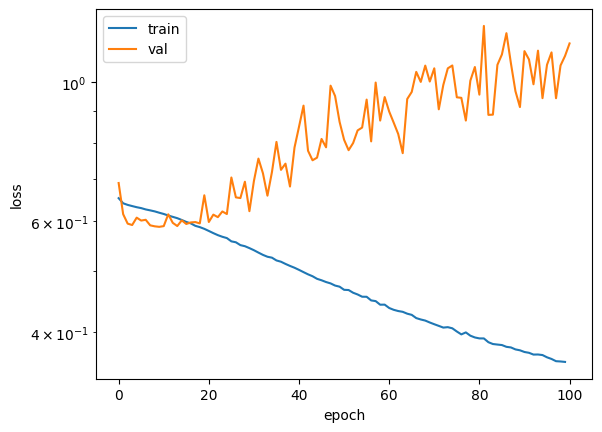

In [ ]:
metrics = trainer.callback_metrics
print(metrics)

#import seaborn as sns
print(history.train_loss)
print(history.val_loss)
plt.plot(history.train_loss, label="train")
plt.plot(history.val_loss, label="val")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

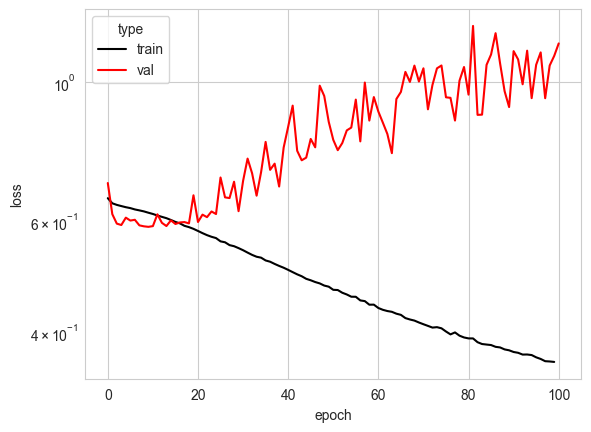

In [ ]:
df = pd.DataFrame({
    "epoch": range(len(history.val_loss)),
    "train": history.train_loss+[np.nan],
    "val": history.val_loss
})
import seaborn as sns

df = df.melt(id_vars="epoch", var_name="type", value_name="loss")

sns.set_style("whitegrid")

plt.figure()
sns.lineplot(data=df, x="epoch", y="loss", hue="type", palette={"train": "black", "val": "red"})

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

df.to_csv("loss_matrix.csv")

In [36]:
fasta_path=f"{DATA_DIR}/GRCm38.fa"
print(fasta_path)
from pyfaidx import Fasta
genome = Fasta(fasta_path)
gene_name = 'Sox2'
chr, start, end = "chr3", 34649995, 34652460
seq = genome[chr][start-1000:start].seq.upper()
inputs = one_hot_encode(seq)
model.eval()
with torch.no_grad():
    x = torch.as_tensor(inputs, dtype=torch.float32)
    output = model(torch.as_tensor(x, dtype=torch.float32).unsqueeze(0))
    print(gene_name, chr, start, end, 'result->', output)
    print(seq)

/content/drive/MyDrive/Colab Notebooks//GRCm38.fa
Sox2 chr3 34649995 34652460 result-> tensor([[0.9220]])
GAGGGAGTTTGTGAGCGCAGCCCAAATGCCACCTCCGCGCCTCGCGGTGGGATGCCAGGAAGTTGCGTGACCCTCCCCCCATCCCCTGCACTCGGGAGCTTCTTTCCGTTGATGCTTTCGTCCCCAAGGTTTCCTCTGAAACTGCCACCACTAAAAATCCTCTTGTGTCAGGGTTGGGAGTTAGAAAGAGCGGGAGCAGAGTTCCAGCTTTGCCTTTGCACCCTTTGGATGGGGCAGGTTGGTGGAGTAGGGAATTAGGGGTTGAGGACACGTGCTGCGGTTCCTTGAGCCACACCTGAGTCGGCCTAGGAAAAGGCTGGGAACAAGGCCTGGTCCTAGCTCTGCTCTACAGTCAGCTACATGGGCAGAGGACTCGTGTTTGGGAACCGAGCCGATGACACGGAAGCCAGGAGGGCGCTGAGGCCCGAGGCTTGGGTCTAACTTCTCGTCTGTACGGTGAGAAGAGGGGGTGAGTGGGTGCTGGCGACAAGGTTGGAAGAGGGGCTGCGACAGAGCGCAGTGCCGCGGATGAGCGCAGAAACAATGGCACACCACCTCCGGCTCTGCCAGCTTCCTGAAATACTAGTTGGACAGTCGCCCTGAACCACCCATGGGCCTTGCCCCACCCTGGCCCCAGCTTCCCGCGCCCCATCCACCCTTATGTATCCAAGAGAGAGCCAATATTCCGTAGCATGGGGGAAAGGAGCTGTCGTCTTGGTGCTGTTTACCCACTTCCTTCGAACAGGCGTGCGCCGTGACCTGTTGCTGAAAACGGGGGGCGGGGGGGGGGGATACAAAGGTTCCCCAGCGGCCGGCTGCGGGCCCGCCTCCCCCGCGCGGTTCGGGGCACAGCGCTCTGCTGGGCTCGGCTCGGCGGCGCGGCAGGCCCCGCCC